In [1]:
import os
os.environ.setdefault("PYTENSOR_FLAGS", "cxx=")
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("../data/anscombe.csv")


In [4]:
df.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


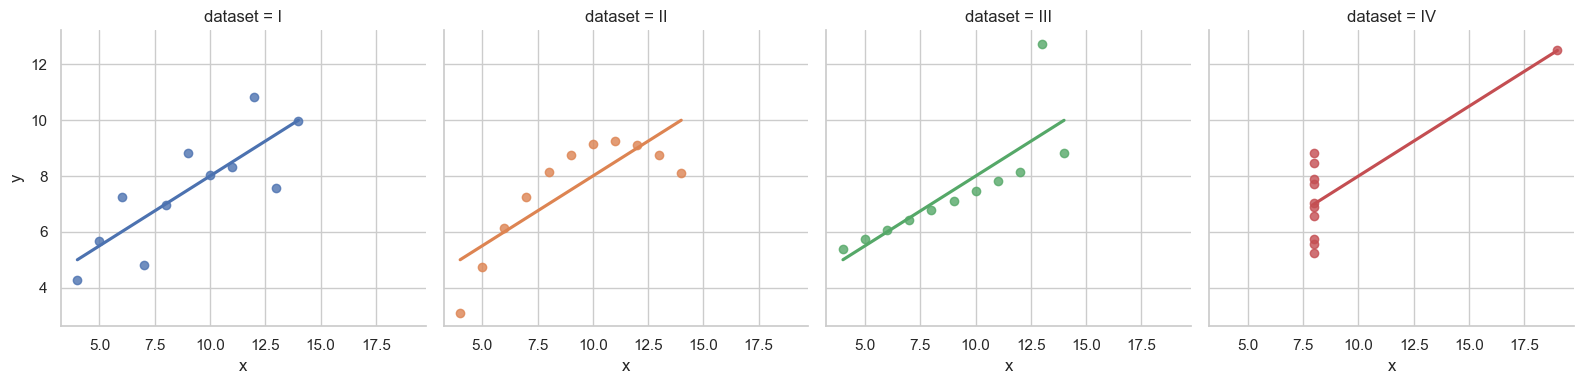

In [5]:
sns.lmplot(
    data=df,
    x="x",
    y="y",
    col="dataset",
    hue="dataset",
    ci=None,
    height=4,
    aspect=1
);

In [6]:
data_iii = df[df["dataset"] == "III"].copy()

x = data_iii["x"].values
y = data_iii["y"].values

In [7]:
x_mean = x.mean()
x_std = x.std()

x_scaled = (x - x_mean) / x_std

In [8]:
with pm.Model() as robust_model:

    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    mu = alpha + beta * x_scaled

    y_obs = pm.StudentT(
        "y_obs",
        nu=3,
        mu=mu,
        sigma=sigma,
        observed=y
    )

    trace_robust = pm.sample(
        draws=200,
        tune=200,
        chains=2,
        cores=1,
        progressbar=False,
        compile_kwargs={"mode": "NUMBA"},
        target_accept=0.98,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, beta, sigma]
Sampling 2 chains for 200 tune and 200 draw iterations (400 + 400 draws total) took 7 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [9]:
az.summary(trace_robust, var_names=["alpha", "beta", "sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,7.114,0.002,7.111,7.118,0.0,0.0,247.0,192.0,1.00
beta,1.092,0.002,1.089,1.095,0.0,0.0,252.0,281.0,1.01
sigma,0.005,0.002,0.002,0.008,0.0,0.0,214.0,287.0,1.01


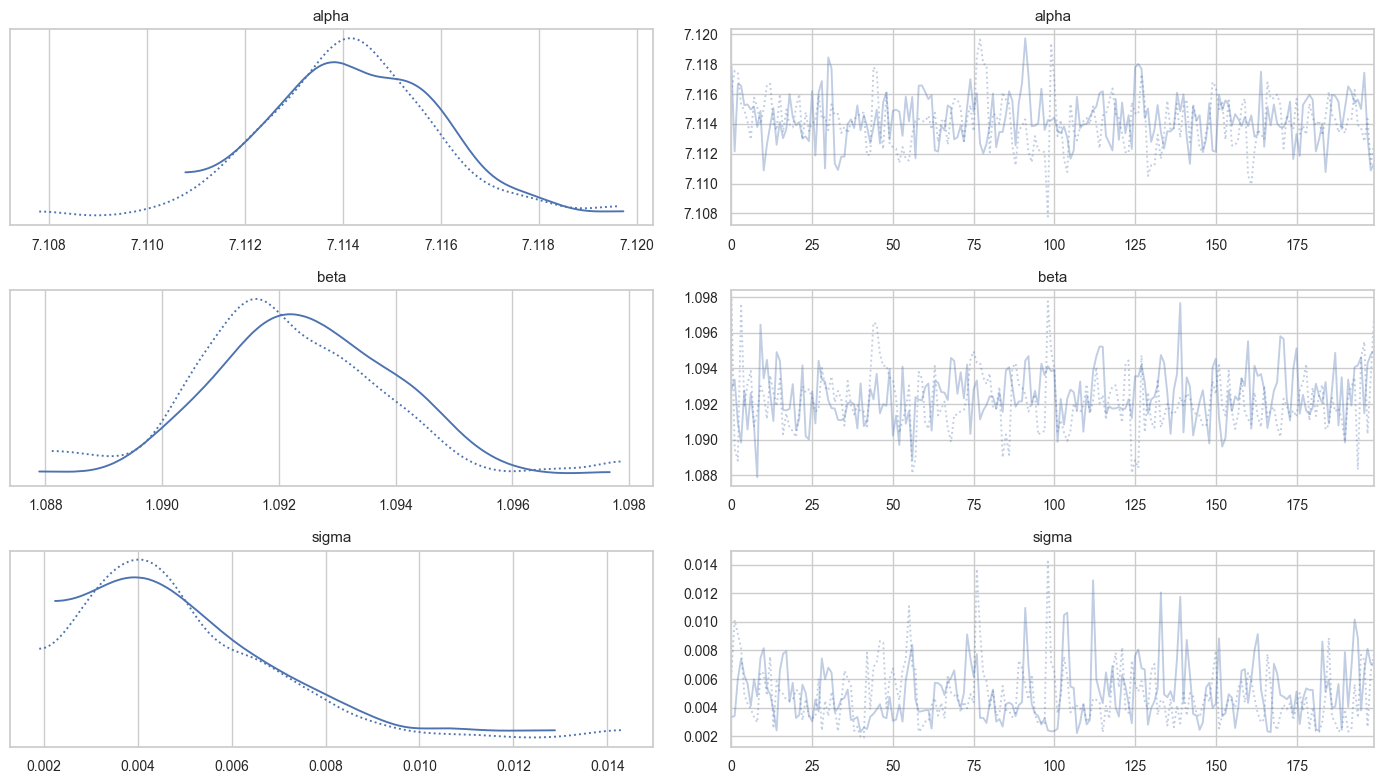

In [10]:
az.plot_trace(
    trace_robust,
    var_names=["alpha", "beta", "sigma"],
    figsize=(14, 8)
)

plt.tight_layout();

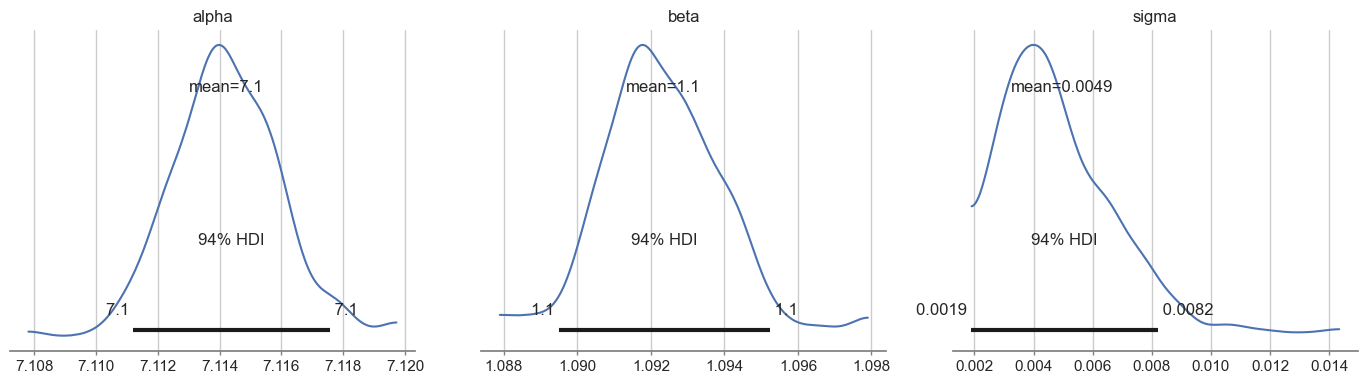

In [11]:
az.plot_posterior(
    trace_robust,
    var_names=["alpha", "beta", "sigma"],
    figsize=(14, 4)
)

plt.tight_layout();

In [12]:
posterior = trace_robust.posterior

alpha_samples = posterior["alpha"].stack(sample=("chain", "draw")).values
beta_samples = posterior["beta"].stack(sample=("chain", "draw")).values

x_grid = np.linspace(x_scaled.min(), x_scaled.max(), 100)

y_lines = alpha_samples[:, None] + beta_samples[:, None] * x_grid[None, :]

y_mean = y_lines.mean(axis=0)
y_hdi = az.hdi(y_lines, hdi_prob=0.94)

C:\Users\Admin\AppData\Local\Temp\ipykernel_2068\3883998849.py:11: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  y_hdi = az.hdi(y_lines, hdi_prob=0.94)


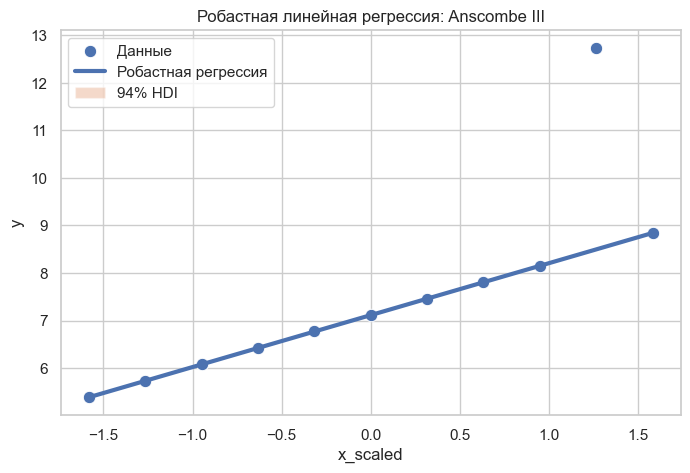

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=x_scaled, y=y, s=80, label="Данные")

plt.plot(x_grid, y_mean, linewidth=3, label="Робастная регрессия")

plt.fill_between(
    x_grid,
    y_hdi[:, 0],
    y_hdi[:, 1],
    alpha=0.3,
    label="94% HDI"
)

plt.xlabel("x_scaled")
plt.ylabel("y")
plt.title("Робастная линейная регрессия: Anscombe III")
plt.legend();

In [14]:
with robust_model:
    ppc = pm.sample_posterior_predictive(
        trace_robust,
        var_names=["y_obs"],
        random_seed=42
    )

Sampling: [y_obs]


Output()

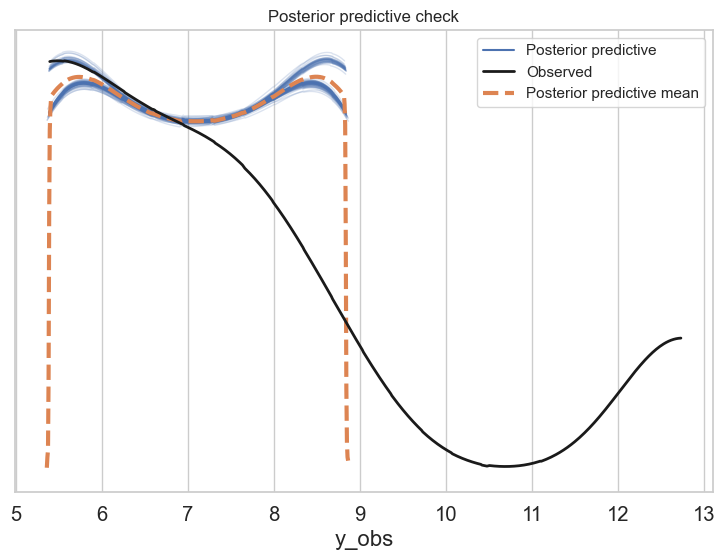

In [15]:
az.plot_ppc(
    ppc,
    num_pp_samples=100,
    figsize=(9, 6)
)

plt.title("Posterior predictive check");